# TMDB Visualizations

This notebook uses Matplotlib, Seaborn, and Plotly to explore univariate, bivariate, and multivariate patterns in the TMDB movie data. Every chart is followed by a short interpretation of the observed pattern.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

DATA_DIR_CANDIDATES = [Path.cwd() / 'Dataset', Path.cwd().parent / 'Dataset', Path.cwd(), Path.cwd().parent]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if (path / 'movies.csv').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not find Dataset/movies.csv from the current working directory.')

def load_csv(name):
    frame = pd.read_csv(DATA_DIR / f'{name}.csv', keep_default_na=False)
    for column in frame.select_dtypes(include='object').columns:
        frame[column] = frame[column].astype('string').str.strip()
    return frame.drop_duplicates().reset_index(drop=True)

movies = load_csv('movies')
genres = load_csv('genres')
movie_genres = load_csv('movie_genres')
cast = load_csv('cast')
for column in ['movie_id', 'runtime', 'budget', 'revenue', 'vote_count']:
    movies[column] = pd.to_numeric(movies[column], errors='coerce')
for column in ['popularity', 'vote_average']:
    movies[column] = pd.to_numeric(movies[column], errors='coerce')
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_year'] = movies['release_date'].dt.year
movies['budget_available'] = movies['budget'].notna() & movies['budget'].gt(0)
movies['revenue_available'] = movies['revenue'].notna() & movies['revenue'].gt(0)
for frame in [genres, movie_genres, cast]:
    for column in ['genre_id', 'movie_id', 'person_id']:
        if column in frame:
            frame[column] = pd.to_numeric(frame[column], errors='coerce')
genre_order = movie_genres.dropna(subset=['movie_id', 'genre_id']).copy()
genre_order['genre_order'] = genre_order.groupby('movie_id').cumcount()
primary_genres = genre_order.loc[genre_order['genre_order'].eq(0), ['movie_id', 'genre_id']].merge(genres[['genre_id', 'genre_name']], on='genre_id', how='left').merge(movies[['movie_id', 'title', 'popularity', 'revenue', 'budget', 'vote_average']], on='movie_id', how='left')
sns.set_theme(style='whitegrid', palette='deep')
print(f'Loaded {len(movies):,} movies from {DATA_DIR.resolve()}')

Loaded 2,503 movies from D:\Guvi\TMDB_Movie_Analytics\Dataset


C:\Users\nihaa\AppData\Local\Temp\ipykernel_8360\2016391139.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in frame.select_dtypes(include='object').columns:
C:\Users\nihaa\AppData\Local\Temp\ipykernel_8360\2016391139.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_

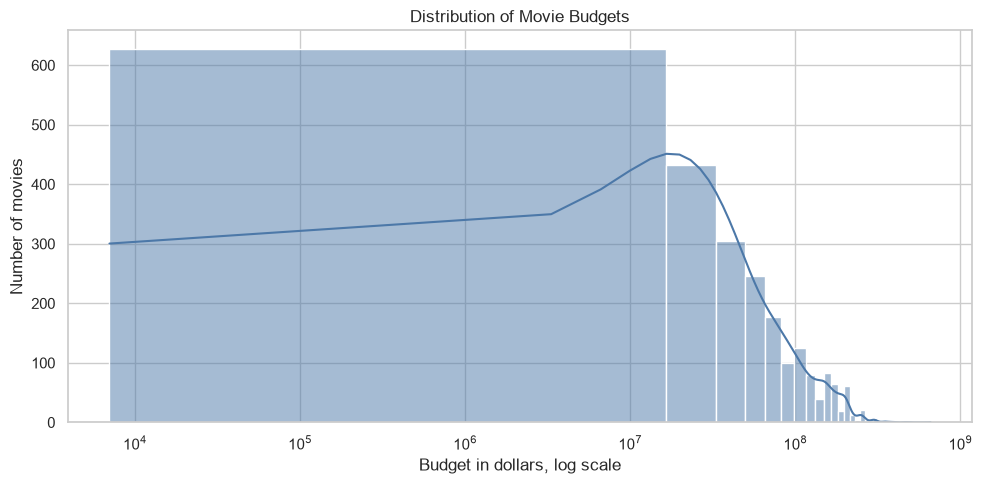

Insight: Movie budgets are strongly right-skewed, with most productions concentrated at lower and mid-range spending levels.
The long upper tail shows that a small number of blockbusters operate at a much larger financial scale than the typical movie.


In [2]:
# Univariate: Distribution of movie budgets
budget_values = movies.loc[movies['budget_available'], 'budget']
plt.figure(figsize=(10, 5))
sns.histplot(budget_values, bins=40, kde=True, color='#4c78a8')
plt.xscale('log')
plt.title('Distribution of Movie Budgets')
plt.xlabel('Budget in dollars, log scale')
plt.ylabel('Number of movies')
plt.tight_layout()
plt.show()
print('Insight: Movie budgets are strongly right-skewed, with most productions concentrated at lower and mid-range spending levels.')
print('The long upper tail shows that a small number of blockbusters operate at a much larger financial scale than the typical movie.')

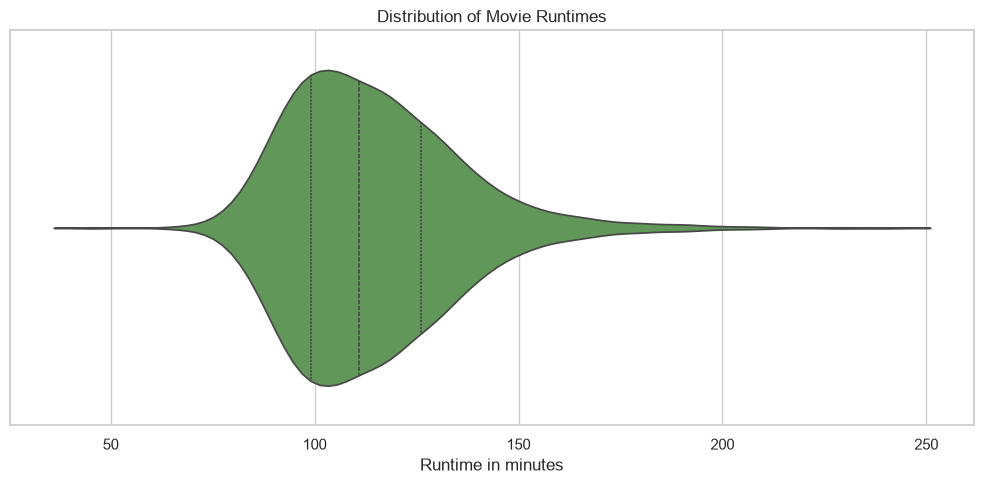

Insight: Movie runtimes cluster around the feature-film range, with a median of 111 minutes.
The extended tails indicate a smaller set of unusually short and unusually long productions, which may deserve separate context during analysis.


In [3]:
# Univariate: Distribution of runtimes
runtime_values = movies.loc[movies['runtime'].gt(0), 'runtime']
plt.figure(figsize=(10, 5))
sns.violinplot(x=runtime_values, color='#59a14f', inner='quartile')
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime in minutes')
plt.tight_layout()
plt.show()
print(f'Insight: Movie runtimes cluster around the feature-film range, with a median of {runtime_values.median():.0f} minutes.')
print('The extended tails indicate a smaller set of unusually short and unusually long productions, which may deserve separate context during analysis.')

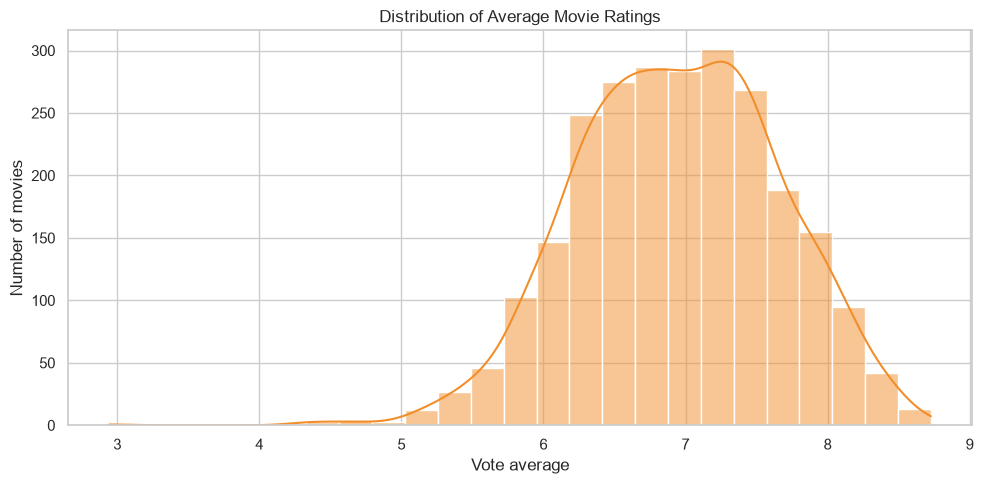

Insight: Ratings are concentrated in the middle-to-high portion of the scale rather than being evenly distributed across all possible scores.
This concentration suggests that the average rating is useful for comparing titles, but small vote counts should still be treated cautiously.


In [4]:
# Univariate: Distribution of vote-average scores
rating_values = movies.loc[movies['vote_average'].notna() & movies['vote_average'].gt(0), 'vote_average']
plt.figure(figsize=(10, 5))
sns.histplot(rating_values, bins=25, kde=True, color='#f28e2b')
plt.title('Distribution of Average Movie Ratings')
plt.xlabel('Vote average')
plt.ylabel('Number of movies')
plt.tight_layout()
plt.show()
print('Insight: Ratings are concentrated in the middle-to-high portion of the scale rather than being evenly distributed across all possible scores.')
print('This concentration suggests that the average rating is useful for comparing titles, but small vote counts should still be treated cautiously.')

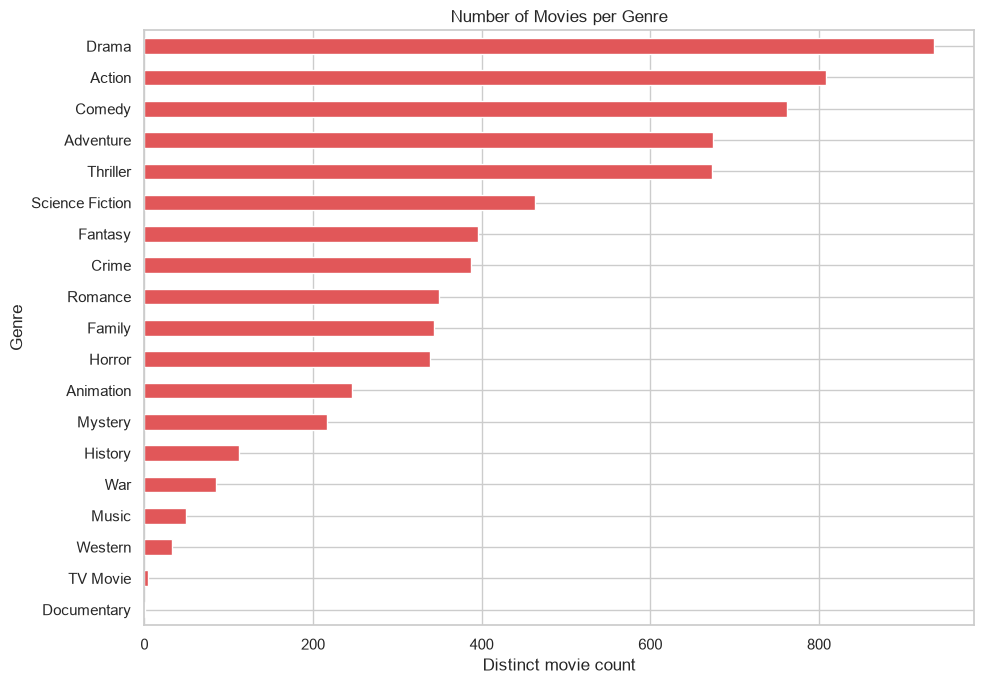

Insight: Drama is the largest genre category in the relationship table, while several specialist genres have much smaller catalogs.
Because movies can belong to multiple genres, these counts describe overlapping genre membership rather than mutually exclusive groups.


In [5]:
# Univariate: Number of movies per genre
genre_counts = movie_genres.merge(genres, on='genre_id').groupby('genre_name')['movie_id'].nunique().sort_values(ascending=True)
plt.figure(figsize=(10, 7))
genre_counts.plot(kind='barh', color='#e15759')
plt.title('Number of Movies per Genre')
plt.xlabel('Distinct movie count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()
print(f'Insight: {genre_counts.index[-1]} is the largest genre category in the relationship table, while several specialist genres have much smaller catalogs.')
print('Because movies can belong to multiple genres, these counts describe overlapping genre membership rather than mutually exclusive groups.')

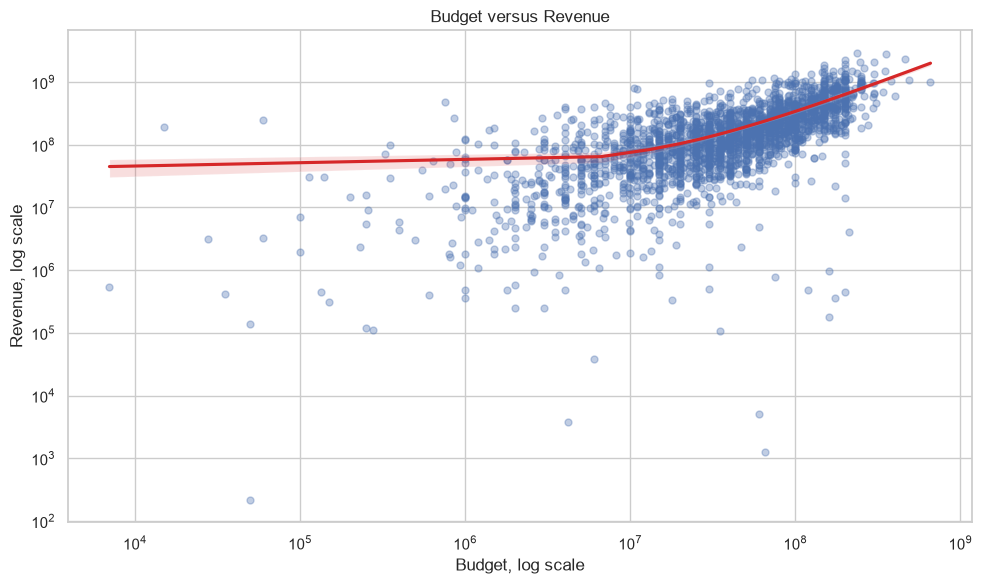

Insight: The positive trend indicates that larger budgets are generally associated with larger revenues, but the broad scatter shows substantial uncertainty around that relationship.
Some lower-budget movies sit well above the trend, demonstrating why budget size alone is not a reliable measure of commercial success.


In [6]:
# Bivariate: Budget versus revenue with trend line
finance_plot = movies.loc[movies['budget_available'] & movies['revenue_available']].copy()
plt.figure(figsize=(10, 6))
sns.regplot(data=finance_plot, x='budget', y='revenue', scatter_kws={'alpha': 0.35, 's': 25}, line_kws={'color': '#d62728'})
plt.xscale('log')
plt.yscale('log')
plt.title('Budget versus Revenue')
plt.xlabel('Budget, log scale')
plt.ylabel('Revenue, log scale')
plt.tight_layout()
plt.show()
print('Insight: The positive trend indicates that larger budgets are generally associated with larger revenues, but the broad scatter shows substantial uncertainty around that relationship.')
print('Some lower-budget movies sit well above the trend, demonstrating why budget size alone is not a reliable measure of commercial success.')

In [7]:
# Bivariate: Popularity versus vote count
popularity_plot = movies.loc[movies['popularity'].notna() & movies['vote_count'].notna()].copy()
figure = px.scatter(popularity_plot, x='vote_count', y='popularity', hover_name='title', hover_data=['release_year', 'vote_average'], log_x=True, opacity=0.6, title='Popularity versus Vote Count')
figure.update_layout(xaxis_title='Vote count, log scale', yaxis_title='Popularity score')
figure.show()
correlation = popularity_plot['popularity'].corr(np.log1p(popularity_plot['vote_count'].clip(lower=0)))
print(f'Insight: Popularity and log-transformed vote count have a correlation of {correlation:.2f}, showing a positive but imperfect association.')
print('The outlying points are analytically useful because they identify movies whose current attention level differs from what their accumulated voting activity would suggest.')

Insight: Popularity and log-transformed vote count have a correlation of 0.31, showing a positive but imperfect association.
The outlying points are analytically useful because they identify movies whose current attention level differs from what their accumulated voting activity would suggest.


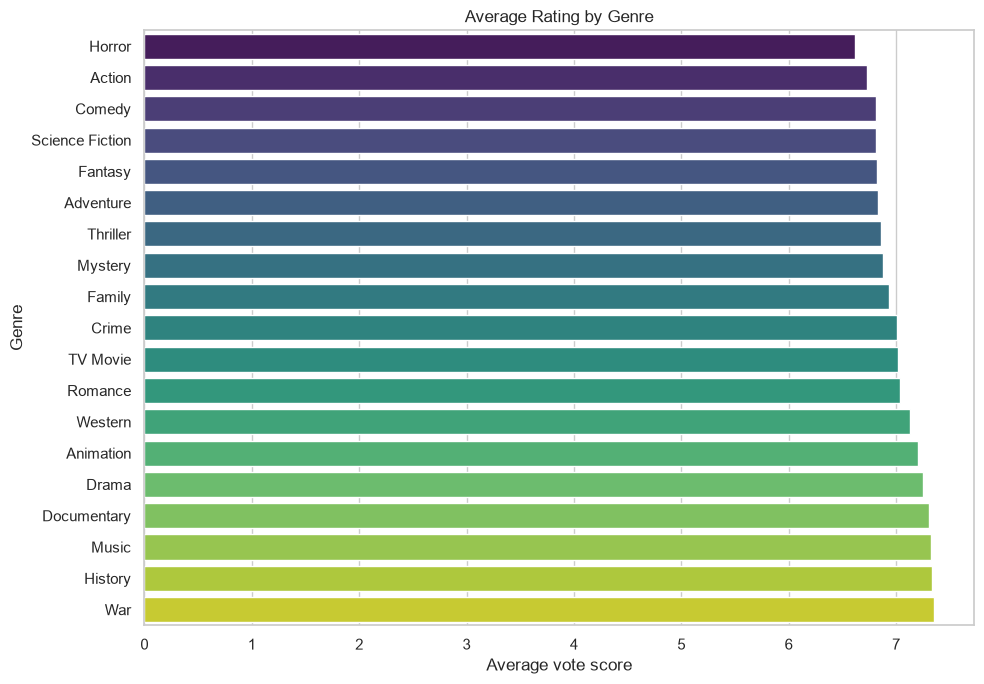

Insight: War has the highest average rating in this comparison, while Horror has the lowest.
Genre averages should be read together with movie counts because a small genre can be more sensitive to a few highly rated titles.


In [9]:
# Bivariate: Average rating by genre
genre_ratings = movie_genres.merge(genres, on='genre_id').merge(movies[['movie_id', 'vote_average']], on='movie_id').groupby('genre_name', as_index=False).agg(average_rating=('vote_average', 'mean'), movie_count=('movie_id', 'nunique')).sort_values('average_rating')
plt.figure(figsize=(10, 7))
sns.barplot(data=genre_ratings, x='average_rating', y='genre_name', hue='genre_name', legend=False, palette='viridis')
plt.title('Average Rating by Genre')
plt.xlabel('Average vote score')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()
best_genre = genre_ratings.iloc[-1]['genre_name']
worst_genre = genre_ratings.iloc[0]['genre_name']
print(f'Insight: {best_genre} has the highest average rating in this comparison, while {worst_genre} has the lowest.')
print('Genre averages should be read together with movie counts because a small genre can be more sensitive to a few highly rated titles.')

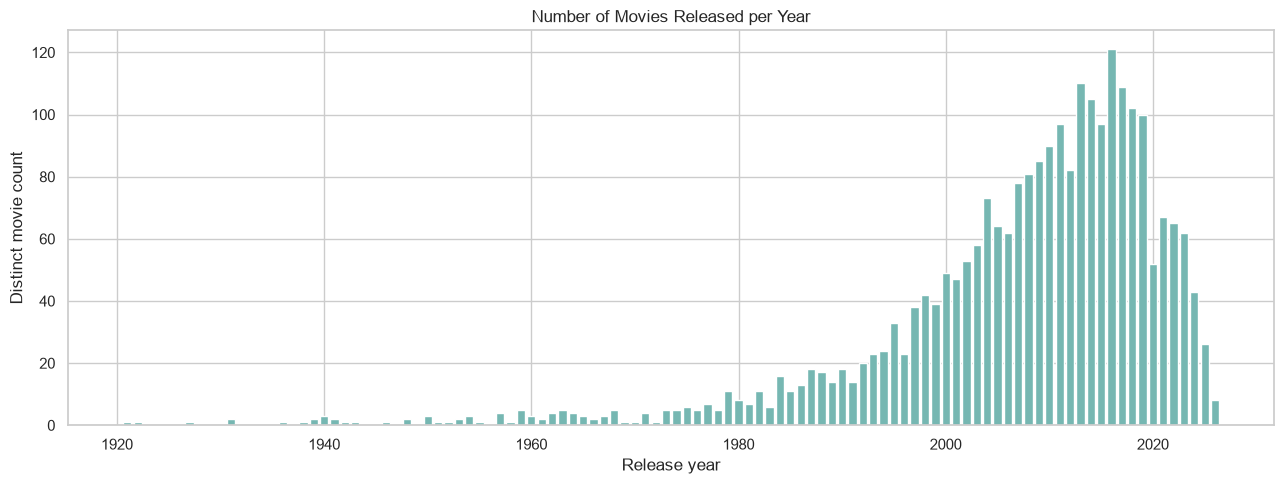

Insight: Movie output rises substantially in the modern part of the dataset and reaches its maximum at 2016 with 121 movies.
The shape reflects both changes in production and the coverage of the source data, so recent incomplete years should not be compared as if they were final.


In [10]:
# Bivariate: Number of movies released per year
year_counts = movies.dropna(subset=['release_year']).groupby('release_year')['movie_id'].nunique()
plt.figure(figsize=(13, 5))
plt.bar(year_counts.index, year_counts.values, color='#76b7b2')
plt.title('Number of Movies Released per Year')
plt.xlabel('Release year')
plt.ylabel('Distinct movie count')
plt.tight_layout()
plt.show()
peak_year = year_counts.idxmax()
print(f'Insight: Movie output rises substantially in the modern part of the dataset and reaches its maximum at {int(peak_year)} with {int(year_counts.loc[peak_year]):,} movies.')
print('The shape reflects both changes in production and the coverage of the source data, so recent incomplete years should not be compared as if they were final.')

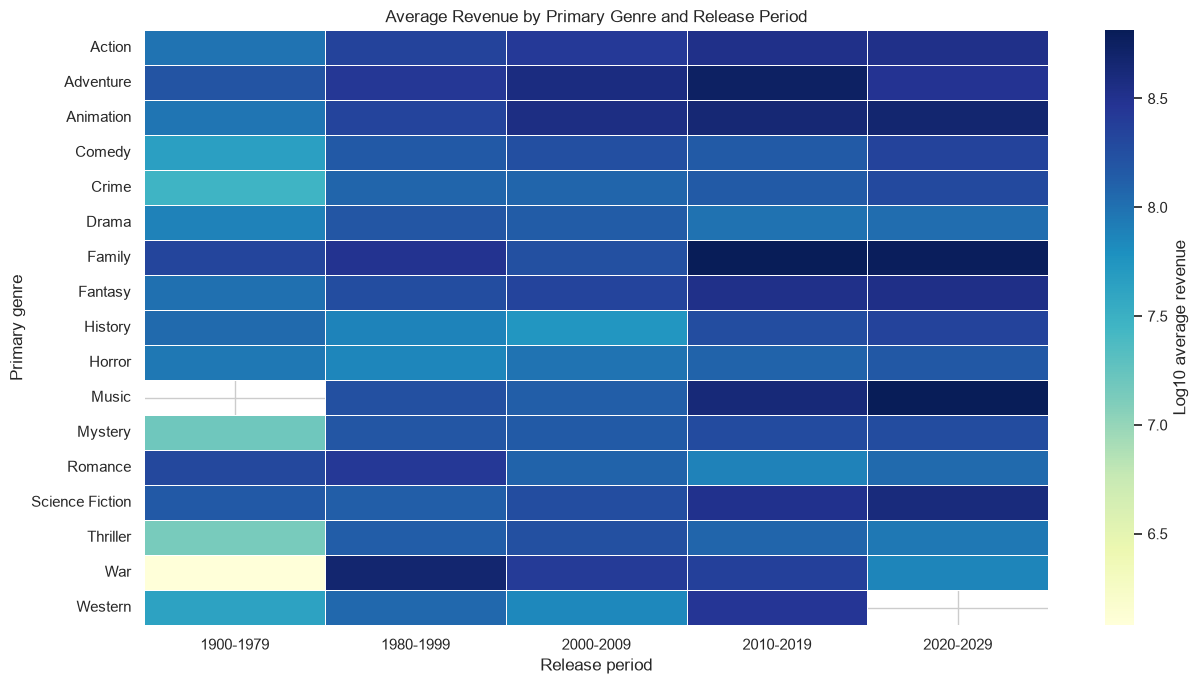

Insight: The heatmap shows how financial performance varies jointly by genre and time period instead of treating either factor in isolation.
Using a logarithmic color scale reduces the visual dominance of blockbuster revenues and makes cross-genre differences easier to inspect.


In [11]:
# Multivariate: Revenue by genre and release period
primary_genres['release_year'] = primary_genres['movie_id'].map(movies.set_index('movie_id')['release_year'])
primary_genres['period'] = pd.cut(primary_genres['release_year'], bins=[1900, 1979, 1999, 2009, 2019, 2030], labels=['1900-1979', '1980-1999', '2000-2009', '2010-2019', '2020-2029'])
genre_period = primary_genres.loc[primary_genres['revenue'].gt(0)].pivot_table(index='genre_name', columns='period', values='revenue', aggfunc='mean', observed=False)
plt.figure(figsize=(13, 7))
sns.heatmap(np.log10(genre_period), cmap='YlGnBu', linewidths=0.4, cbar_kws={'label': 'Log10 average revenue'})
plt.title('Average Revenue by Primary Genre and Release Period')
plt.xlabel('Release period')
plt.ylabel('Primary genre')
plt.tight_layout()
plt.show()
print('Insight: The heatmap shows how financial performance varies jointly by genre and time period instead of treating either factor in isolation.')
print('Using a logarithmic color scale reduces the visual dominance of blockbuster revenues and makes cross-genre differences easier to inspect.')

In [12]:
# Multivariate: Genre volume, popularity, and rating
genre_profile = primary_genres.groupby('genre_name', as_index=False).agg(movie_count=('movie_id', 'nunique'), average_popularity=('popularity', 'mean'), average_rating=('vote_average', 'mean')).dropna()
figure = px.scatter(genre_profile, x='movie_count', y='average_popularity', size='average_rating', color='average_rating', hover_name='genre_name', text='genre_name', color_continuous_scale='Turbo', title='Genre Volume, Popularity, and Rating')
figure.update_traces(textposition='top center')
figure.update_layout(xaxis_title='Number of movies', yaxis_title='Average popularity', coloraxis_colorbar_title='Average rating')
figure.show()
print('Insight: This multivariate view distinguishes broad genre representation from popularity and critical reception, which do not necessarily move together.')
print('Genres near the upper-left are popular despite smaller catalogs, while genres on the right have greater volume and should be evaluated with that scale in mind.')

Insight: This multivariate view distinguishes broad genre representation from popularity and critical reception, which do not necessarily move together.
Genres near the upper-left are popular despite smaller catalogs, while genres on the right have greater volume and should be evaluated with that scale in mind.
